---
title: "Duinen"
execute:
  warning: false
  error: false
---

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

import pydra_core as pydra

Als demonstratie worden de hydraulische belastingen voor (Schiermonnikoog) bepaald. Hieronder definiëren we de locatie van de database.

In [2]:
DB_PATH = "data/B2035_Duinen_1-1_v01.sqlite"

<h3>HRDatabase</h3>

Met de HR database maken we een <i>HRDatabase</i> aan. Dit object beheert alle locaties in de HR database en helpt om batch berekeningen te maken.

In [3]:
hrdatabase = pydra.HRDatabase(DB_PATH)

Eén van de functies van een <i>HRDatabase</i> object is het uitlezen van de namen van alle uitvoerpunten.

In [4]:
hrdatabase.get_location_names()

['Schiermonnikoog_2_100',
 'Schiermonnikoog_2_101',
 'Schiermonnikoog_2_102',
 'Schiermonnikoog_2_103',
 'Schiermonnikoog_2_104',
 'Schiermonnikoog_2_105',
 'Schiermonnikoog_2_106',
 'Schiermonnikoog_2_120',
 'Schiermonnikoog_2_140',
 'Schiermonnikoog_2_160',
 'Schiermonnikoog_2_180',
 'Schiermonnikoog_2_200',
 'Schiermonnikoog_2_201',
 'Schiermonnikoog_2_202',
 'Schiermonnikoog_2_203',
 'Schiermonnikoog_2_204',
 'Schiermonnikoog_2_205',
 'Schiermonnikoog_2_206',
 'Schiermonnikoog_2_220',
 'Schiermonnikoog_2_240',
 'Schiermonnikoog_2_260',
 'Schiermonnikoog_2_280',
 'Schiermonnikoog_2_300',
 'Schiermonnikoog_2_301',
 'Schiermonnikoog_2_302',
 'Schiermonnikoog_2_303',
 'Schiermonnikoog_2_304',
 'Schiermonnikoog_2_320',
 'Schiermonnikoog_2_340',
 'Schiermonnikoog_2_360',
 'Schiermonnikoog_2_380',
 'Schiermonnikoog_2_400',
 'Schiermonnikoog_2_401',
 'Schiermonnikoog_2_420',
 'Schiermonnikoog_2_440',
 'Schiermonnikoog_2_460',
 'Schiermonnikoog_2_480',
 'Schiermonnikoog_2_500',
 'Schiermonn

<h3>Settings</h3>

Met het <i>HRDatabase</i> maken we een <i>Settings</i> object aan voor het HR-uitvoerpunt 'Schiermonnikoog_2_800'. Het <i>Settings</i> object is voor Pydra hetzelfde als het 'invoer.hyd' bestand voor Hydra-NL is.

In [5]:
settings = hrdatabase.get_settings("Schiermonnikoog_2_800")

Het is mogelijk om alle settings uit te lezen door het <i>Settings</i> object te printen.

In [6]:
print(settings)

database_path                  = data/B2035_Duinen_1-1_v01.sqlite
location                       = Schiermonnikoog_2_800
water_level_correction         = 0.0
watersystem                    = WaterSystem.COAST_DUNES
x_coordinate                   = 209584
y_coordinate                   = 612853


Voordat berekeningen worden gedaan is het mogelijk om het <i>Settings</i> object aan te passen:

In [7]:
print("Origineel:", settings.sea_level_rise)
settings.sea_level_rise = 0.0
print("Aangepast:", settings.sea_level_rise)

Origineel: None
Aangepast: 0.0


<h3>Location</h3>

Wanneer je tevreden bent met de settings in het <i>Settings</i> object, kan een <i>Location</i> object worden aangemaakt. Wanneer een location wordt aangemaakt lees Pydra de statistiek in en worden belastingsmodellen gegenereert. De belastingsmodellen en de statistiek worden geïnitieerd op basis van de eerder gekoppelde HR database in het <i>HRDatabase</i> object.

In [8]:
location = hrdatabase.create_location(settings)

Nu het <i>Location</i> object is aangemaakt voor het HR uitvoerpunt 'Schiermonnikoog_2_800', kan deze gebruikt worden in berekeningen.

<h3>Hydraulische Belastingen voor één uitvoerpunt</h3>

Pydra heeft verschillende rekenmodules (objecten). Hieronder gebruiken we de <i>HydraulicLoadsDunes</i> module om de hydraulische belastingen voor duinen te berekenen. Voordat we dat kunnen doen moet eerst een rekenobject worden aangemaakt, hieronder <i>hl</i>. Het rekenobject omvat de instellingen voor de berekening, zoals de terugkeertijd. Voor de duinen worden altijd waterstand (rekenpeil), golfhoogte en golfperiode gezamenlijk berekend. Daarnaast is er nog een optionele optie, of er met modelonzekerheden moet worden gerekend (standaard : True).

In [9]:
hl = pydra.HydraulicLoadsDunes(return_period=3_000, model_uncertainty=True)

Vervolgens kunnen we met het rekenobject <i>hl</i> hydraulische belastingen worden bepaald voor HR uitvoerpunt 'Schiermonnikoog_2_800' door de <i>calculate()</i> functie aan te roepen van het rekenobject en het <i>location</i> object als argument mee te geven. Hier zijn ook nog optionele opties, of het resultaat wordt opgeslagen in een .bnd bestand (standaard: False) en of het resultaat van de FORM berekening wordt weggeschreven (standaard: False).

In [10]:
hydraulic_loads = hl.calculate(location, save=False, make_plot=False)

INFO: T = 3000 yr  →  β = 3.402933  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_800  (raai 8000,  ΔH = 0.0000 m)


Dit geeft de hydraulische belastingen <i>hydraulic_loads</i>. Het is een object waarin de berekende gegevens (waterstand, golfhoogte, golfperiode) worden opgeslagen. Als je het object print, zie je wat er allemaal in zit.

In [11]:
print(hydraulic_loads)

[{'jarkus_raai': 8000, 'bnd_nr': 800, 'return_period': 3000, 'u_wl_star': 3.3431, 'u_stat_star': 0.6356, 'rp': 4.634, 'hs': 10.784, 'tp': 19.317, 'getij': 1.0524, 'fase': 3.5, 'spread': 6.0, '_thetas': array([0.00000000e+00, 1.57095342e-04, 3.14190684e-04, ...,
       1.57048214e+00, 1.57063923e+00, 1.57079633e+00]), '_h_arc': array([4.56002137, 4.56014001, 4.56025856, ..., 2.24204427, 2.24182384,
       2.2416034 ]), '_u_wl_grid': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5], '_u_stat_grid': [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0], '_h_fn': <function HydraulicLoadsDunes.calculate_location.<locals>._h_blended at 0x000001FC5A1D2160>, '_u_stat_max_eff': 3.402932835385335}]


We hebben dezelfde berekening gemaakt met Hydra-Ring, wat de onderstaande vergelijking geeft.

In [12]:
bnd_file = r"benchmark/HR_Duinen_1-1_B2035_v01_T3000.bnd"

df = pd.read_csv(
    bnd_file,
    sep="\t",
    comment="*",
    encoding="utf-8",
)

print("Hydra-Ring: \n",df[df["Nr"] == 800])

Hydra-Ring: 
     Kv   Nr    Rp     Hs     Tp  Getij   dt  _BOI2023_Waarde
54   2  800  4.63  10.78  19.31   1.05  3.5         0.000333


In [13]:
cols = ["bnd_nr", "rp", "hs", "tp", "getij", "fase", "return_period"]
print("Pydra:\n", pd.DataFrame(hydraulic_loads)[cols])

Pydra:
    bnd_nr     rp      hs      tp   getij  fase  return_period
0     800  4.634  10.784  19.317  1.0524   3.5           3000


<h3>Opzet profiel en uitvoerpunt</h3>

Als demonstratie wordt XBeach 1D doorgerekend voor Schiermonnikoog voor uitvoerpunt 'Schiermonnikoog_2_800'.

Eerst maken we een nieuwe profiel aan. We nemen een schematisatie over vanuit Jarkusraai 8000 en een duinnormaal van 330 graden. Hieronder is de code weergegeven. Voor meer informatie over het schematiseren van profielen zie notebook '02. Profielen.ipynb'.

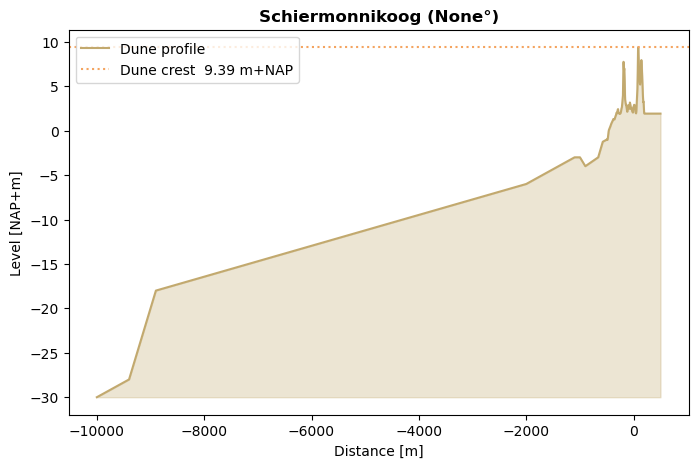

In [14]:
# Maak duinprofiel (x = dwarsraai richting, y = hoogte m+NAP)
profile = pydra.Profile("Schiermonnikoog")
# profile.set_dune_orientation(330)
profile.set_dune_geometry(
    dune_x = [-10000,-9400,-8900,-2000,-1100,-1000,-900,-660,-575,-500,-495.39,-487.34,-479.73,-472.90,-466.66,-460.83,-455.15,-449.63,-444.26,-439.05,-434.03,-429.18,-424.48,-419.97,-415.58,-411.31,-407.15,-403.09,-399.11,-395.22,-391.44,-387.78,-384.25,-380.82,-377.44,-374.06,-370.66,-367.24,-363.78,-360.30,-356.86,-353.52,-350.31,-347.24,-344.28,-341.43,-338.67,-335.99,-333.37,-330.83,-328.38,-326.04,-323.81,-321.72,-319.74,-317.74,-315.71,-313.65,-311.57,-309.49,-307.53,-305.66,-303.87,-302.14,-300.46,-298.91,-297.49,-296.19,-295.00,-293.82,-292.64,-291.48,-290.26,-288.86,-287.24,-285.39,-283.45,-281.46,-279.44,-277.42,-275.40,-273.34,-271.23,-269.07,-266.89,-264.70,-262.54,-260.40,-258.31,-256.29,-254.28,-252.21,-250.07,-247.97,-245.91,-243.90,-241.94,-240.02,-238.18,-236.43,-234.76,-233.25,-231.88,-230.63,-229.47,-228.38,-227.34,-226.34,-225.34,-224.34,-223.34,-222.34,-221.34,-220.34,-219.34,-218.34,-217.34,-216.34,-215.34,-214.34,-213.34,-212.34,-211.34,-210.34,-209.34,-208.34,-207.34,-206.34,-205.34,-204.34,-203.34,-202.34,-201.34,-200.34,-199.34,-198.34,-197.34,-196.34,-195.34,-194.34,-193.34,-192.34,-191.34,-190.34,-189.34,-188.34,-187.34,-186.34,-185.34,-184.34,-183.34,-182.34,-181.34,-180.34,-179.34,-178.34,-177.34,-176.34,-175.34,-174.34,-173.34,-172.34,-171.34,-170.34,-169.34,-168.34,-167.34,-166.34,-165.34,-164.34,-163.34,-162.34,-161.34,-160.34,-159.34,-158.34,-157.34,-156.34,-155.34,-154.34,-153.34,-152.34,-151.34,-150.34,-149.34,-148.34,-147.34,-146.34,-145.34,-144.34,-143.34,-142.34,-141.34,-140.34,-139.34,-138.34,-137.34,-136.34,-135.34,-134.34,-133.34,-132.34,-131.34,-130.34,-129.32,-128.14,-126.80,-125.28,-123.66,-121.98,-120.25,-118.55,-116.92,-115.32,-113.82,-112.40,-111.08,-109.87,-108.82,-107.82,-106.82,-105.82,-104.82,-103.82,-102.82,-101.82,-100.82,-99.82,-98.82,-97.82,-96.82,-95.82,-94.81,-93.78,-92.73,-91.66,-90.56,-89.46,-88.36,-87.26,-86.16,-85.06,-83.98,-82.92,-81.89,-80.87,-79.87,-78.87,-77.87,-76.87,-75.87,-74.87,-73.87,-72.87,-71.87,-70.87,-69.87,-68.87,-67.87,-66.87,-65.87,-64.87,-63.87,-62.87,-61.87,-60.87,-59.87,-58.87,-57.87,-56.87,-55.87,-54.87,-53.87,-52.87,-51.87,-50.87,-49.87,-48.87,-47.87,-46.82,-45.67,-44.51,-43.40,-42.34,-41.34,-40.34,-39.34,-38.34,-37.34,-36.33,-35.31,-34.23,-33.05,-31.78,-30.39,-28.93,-27.40,-25.79,-24.14,-22.46,-20.75,-18.98,-17.15,-15.24,-13.56,-12.09,-10.82,-9.71,-8.67,-7.67,-6.67,-5.67,-4.67,-3.67,-2.67,-1.67,-0.67,0.32,1.32,2.32,3.32,4.32,5.32,6.32,7.32,8.32,9.32,10.32,11.32,12.32,13.32,14.32,15.32,16.32,17.32,18.32,19.32,20.32,21.32,22.32,23.32,24.32,25.32,26.37,27.59,28.98,30.58,32.30,34.13,36.05,38.01,40.01,42.05,44.13,46.14,47.89,49.41,50.74,51.89,52.89,53.89,54.89,55.89,56.89,57.89,58.89,59.89,60.89,61.89,62.89,63.89,64.89,65.89,66.89,67.89,68.89,69.89,70.89,71.89,72.89,73.89,74.89,75.89,76.89,77.89,78.89,79.89,80.89,81.89,82.89,83.89,84.89,85.89,86.89,87.89,88.89,89.89,90.89,91.89,92.89,93.89,94.89,95.89,96.89,97.89,98.89,99.89,100.89,101.89,102.89,103.89,104.89,105.89,106.89,107.89,108.89,109.89,110.89,111.89,112.89,113.89,114.89,115.89,116.89,117.89,118.89,119.89,120.89,121.89,122.89,123.89,124.89,125.89,126.89,127.89,128.89,129.89,130.89,131.89,132.89,133.89,134.89,135.89,136.89,137.89,138.89,139.89,140.89,141.89,142.89,143.89,144.89,145.89,146.89,147.89,148.89,149.89,150.89,151.89,152.89,153.89,154.89,155.89,156.89,157.89,158.89,159.89,160.89,161.89,162.89,163.89,164.89,165.89,166.89,167.89,168.89,169.89,170.89,171.89,172.89,173.89,174.89,175.89,176.89,177.89,178.89,179.89,180.89,181.89,182.89,183.89,184.89,185.89,186.89,187.90,189.07,190.41,191.95,193.73,195.77,197.86,200.02,500.00],
    dune_y = [-30,-28,-18,-6,-3,-3,-4,-3,-1.25,-1,-0.97,-1.02,-0.80,-0.41,-0.11,0.08,0.16,0.23,0.31,0.39,0.48,0.57,0.65,0.74,0.80,0.86,0.92,0.97,1.01,1.05,1.11,1.17,1.23,1.28,1.31,1.31,1.30,1.29,1.27,1.26,1.28,1.32,1.39,1.46,1.52,1.57,1.62,1.66,1.69,1.73,1.77,1.82,1.88,1.95,2.01,2.00,1.98,1.97,1.96,1.96,2.01,2.06,2.10,2.13,2.16,2.22,2.29,2.34,2.40,2.41,2.41,2.42,2.42,2.33,2.20,2.07,2.02,2.00,1.99,1.99,1.99,1.96,1.94,1.92,1.91,1.90,1.91,1.93,1.95,1.99,1.99,1.96,1.93,1.95,1.97,1.99,2.02,2.03,2.08,2.12,2.16,2.24,2.31,2.37,2.42,2.45,2.48,2.50,2.53,2.55,2.56,2.57,2.58,2.59,2.62,2.67,2.72,2.77,2.82,2.89,2.97,3.04,3.12,3.19,3.24,3.29,3.33,3.37,3.42,3.48,3.55,3.62,3.69,3.76,3.97,4.26,4.54,4.82,5.11,5.54,6.05,6.56,7.06,7.58,7.75,7.74,7.72,7.71,7.70,7.57,7.39,7.20,7.02,6.83,6.80,6.85,6.91,6.97,7.02,6.95,6.81,6.67,6.52,6.38,6.19,5.97,5.75,5.52,5.30,5.01,4.68,4.36,4.03,3.70,3.55,3.50,3.44,3.39,3.33,3.28,3.24,3.20,3.16,3.12,3.08,3.04,3.00,2.95,2.91,2.90,2.90,2.91,2.91,2.91,2.88,2.85,2.82,2.79,2.76,2.72,2.68,2.63,2.59,2.54,2.48,2.41,2.32,2.23,2.19,2.16,2.13,2.15,2.18,2.20,2.24,2.29,2.33,2.38,2.47,2.55,2.64,2.72,2.80,2.81,2.83,2.84,2.86,2.85,2.78,2.70,2.63,2.55,2.49,2.48,2.47,2.46,2.45,2.45,2.45,2.45,2.45,2.45,2.46,2.47,2.48,2.49,2.50,2.53,2.56,2.60,2.63,2.67,2.77,2.88,2.98,3.09,3.17,3.15,3.12,3.10,3.07,3.05,3.01,2.97,2.94,2.91,2.87,2.84,2.81,2.78,2.75,2.71,2.69,2.66,2.63,2.60,2.57,2.54,2.50,2.47,2.42,2.41,2.44,2.47,2.49,2.52,2.52,2.51,2.50,2.49,2.49,2.45,2.41,2.36,2.30,2.26,2.23,2.19,2.17,2.16,2.14,2.11,2.08,2.04,2.15,2.26,2.36,2.44,2.48,2.53,2.57,2.61,2.65,2.65,2.65,2.65,2.65,2.66,2.70,2.75,2.79,2.84,2.87,2.88,2.89,2.89,2.90,2.91,2.90,2.90,2.89,2.88,2.88,2.87,2.87,2.87,2.86,2.85,2.84,2.82,2.81,2.79,2.75,2.63,2.49,2.33,2.19,2.14,2.08,2.04,2.02,1.99,1.97,1.95,1.99,2.06,2.13,2.24,2.38,2.49,2.61,2.73,2.85,2.97,3.09,3.21,3.33,3.45,3.56,3.68,3.79,3.91,4.07,4.23,4.38,4.54,4.70,4.96,5.23,5.50,5.77,6.04,6.54,7.07,7.60,8.13,8.66,8.84,8.98,9.11,9.25,9.39,9.31,9.20,9.08,8.97,8.86,8.67,8.48,8.28,8.08,7.89,7.67,7.46,7.24,7.03,6.81,6.68,6.57,6.45,6.34,6.22,6.10,5.98,5.86,5.74,5.62,5.55,5.49,5.42,5.36,5.30,5.28,5.26,5.23,5.21,5.19,5.24,5.30,5.36,5.42,5.49,5.57,5.65,5.73,5.82,5.90,6.08,6.28,6.48,6.68,6.88,7.07,7.25,7.44,7.62,7.81,7.84,7.87,7.89,7.91,7.94,7.86,7.77,7.68,7.59,7.50,7.38,7.24,7.11,6.98,6.85,6.69,6.54,6.39,6.24,6.09,5.90,5.70,5.50,5.30,5.10,4.93,4.77,4.62,4.46,4.30,4.16,4.02,3.89,3.75,3.61,3.52,3.44,3.37,3.29,3.21,3.22,3.23,3.24,3.24,3.26,3.13,3.00,2.86,2.70,2.52,2.34,2.14,1.98,1.95,1.92,1.92])
location.set_profile(profile)

# Controle plot
profile.draw_profile()

Nu we het duinprofiel geschematiseerd hebben, voegen we het toe aan 'location' door middel van de functie <i>set_profile(Profile)</i>.

In [15]:
location.set_profile(profile)

Je kan een profiel overschrijven door de <i>set_profile(Profile)</i> opnieuw te gebruiken. Je kan een profiel verwijderen door <i>remove_profile()</i> aan te roepen.

<h3>Duinafslag berekenen</h3>

Om Duinafslag (1D) te berekenen gebruiken we het <i>XbeachComputation</i> rekenobject.

In [16]:
xb = pydra.XbeachComputation(hydraulic_loads)

Vervolgens kunnen we met het rekenobject <i>xb</i> de duinafslag bepalen voor HR uitvoerpunt 'Schiermonnikoog_2_800' door de <i>calculate_1D()</i> functie aan te roepen van het rekenobject en het <i>location</i> object als argument mee te geven. Het 1D rekenobject heeft twee optionele argumenten:
<lu>
    <li>save (standaard False): Opslaan van het resultaat (.nc bestand).</li>
    <li>make_plot (standaard False): Opslaan van een figuur met het resterende duinprofiel.</li>
</lu>

In [17]:
xbeach_dune_erosion = xb.calculate_1D(location, save=True, make_plot=True)

INFO: M2 tide: tidal_amp = 1.052 m, tidal_phase = 3.50 h, surge_height = 4.096 m, max(wl) = 4.634 m (rp 4.634 m), tstop = 108000 s (30.0 h)
INFO: D50 = 0.000164 m  (Kv=2, Nr=800.0)
INFO: Running XBeach for raai 8000  (tstop = 108000 s) …
INFO: XBeach simulation finished.
INFO: Resthoogte = 9.20 m+NAP
INFO: XBeach output saved → data\Pydra_XBeach_B2035_Duinen_1-1_v01_T3000_r8000.nc
INFO: XBeach profile plot saved → data\Pydra_XBeach_B2035_Duinen_1-1_v01_T3000_r8000.pdf


Dit geeft de uitvoer <i>xbeach_dune_erosion</i>. Het is een object waarin de paden naar de berekende gegevens (.nc bestand) worden opgeslagen. Als je het object print, zie je wat er allemaal in zit.

In [18]:
print(xbeach_dune_erosion)

{'resthoogte': 9.2, 'xb_path': 'data\\Schiermonnikoog_2_800', 'nc_path': 'data\\Schiermonnikoog_2_800\\xboutput.nc'}


Hieronder is een plot van de berekende duinafslag gegeven. En een vergelijking met de uitkomst uit Morphan.

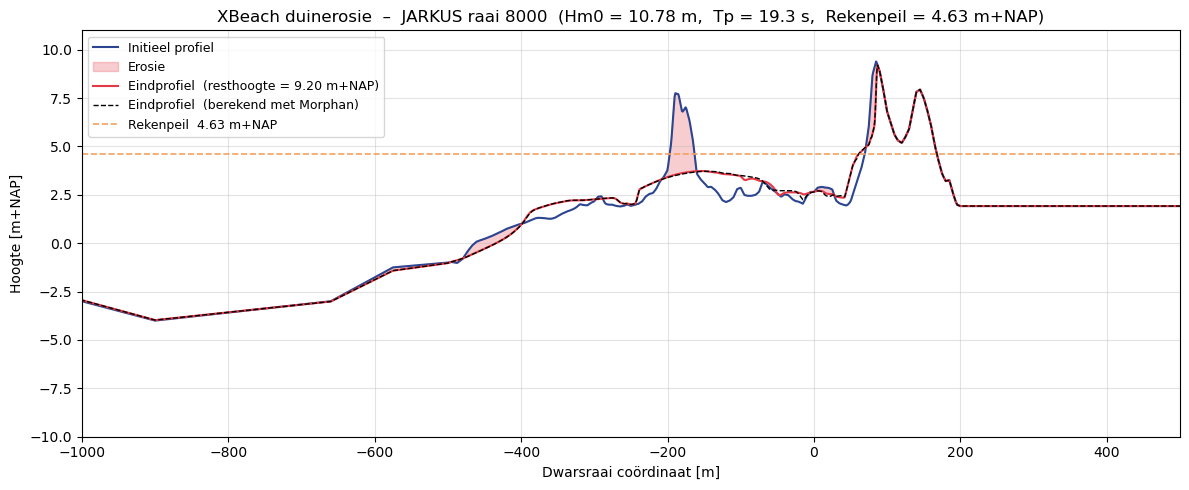

In [28]:
import os
import netCDF4

# ── Load Morphan output ───────────────────────────────────────────────────────
nc_path = r"benchmark/xboutput.nc"
ds_mp = netCDF4.Dataset(nc_path)
zb_ini_mp = np.array(ds_mp["zb"][0,  0, :])
zb_end_mp = np.array(ds_mp["zb"][-1, 0, :])
x_mp = np.array(ds_mp['globalx'][0])

# ── Dune profile plot ─────────────────────────────────────────────────────────
xb_path = xbeach_dune_erosion["xb_path"]
nc_path = xbeach_dune_erosion["nc_path"]
rp      = hydraulic_loads[0]["rp"]
hs      = hydraulic_loads[0]["hs"]
tp      = hydraulic_loads[0]["tp"]
raai    = hydraulic_loads[0]["jarkus_raai"]

x = np.fromstring(open(os.path.join(xb_path, "x.grd")).readline(), sep=" ")
ds = netCDF4.Dataset(nc_path)
zb_ini = np.array(ds["zb"][0,  0, :])
zb_end = np.array(ds["zb"][-1, 0, :])
ds.close()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, zb_ini, color="#2B4590", lw=1.5, label="Initieel profiel")
ax.fill_between(x, zb_ini, zb_end, where=(zb_end < zb_ini),
                color="#E63946", alpha=0.25, label="Erosie")
ax.plot(x, zb_end, color="#E63946", lw=1.5,
        label=f"Eindprofiel  (resthoogte = {xbeach_dune_erosion['resthoogte']:.2f} m+NAP)")
ax.plot(x_mp, zb_end_mp, color="#000000", lw=1.0,
        linestyle= "--", label=f"Eindprofiel  (berekend met Morphan)")
ax.axhline(rp, color="#F4A261", lw=1.2, ls="--",
           label=f"Rekenpeil  {rp:.2f} m+NAP")
ax.set_xlabel("Dwarsraai coördinaat [m]")
ax.set_ylabel("Hoogte [m+NAP]")
ax.set_xlim(-1000, x.max())
ax.set_ylim(-10, 11)
ax.set_title(
    f"XBeach duinerosie  –  JARKUS raai {raai}  "
    f"(Hm0 = {hs:.2f} m,  Tp = {tp:.1f} s,  Rekenpeil = {rp:.2f} m+NAP)"
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)
fig.tight_layout()
plt.show()

<h3>Hydraulische Belastingen voor een heel traject</h3>

Het is ook mogelijk om de Hydraulische Belastingen voor een heel traject te genereren. Laten we weer een rekenobject <i>hl</i> aanmaken. Merk op dat we  ten opzichte van hierboven dit maal <i>return_period = 1000</i> hebben ingesteld.

In [29]:
hrdatabase = pydra.HRDatabase(DB_PATH)

hl = pydra.HydraulicLoadsDunes(return_period=1_000, model_uncertainty=True)

Door het <i>HRDatabase</i> object '<i>hrdatabase</i>' mee te geven als argument in de <i>calculate()</i> functie, bepaald Pydra de hydraulische belastingen voor <u>alle</u> uitvoerpunten in de HR database. Voor uitvoerpunten die nog niet zijn gedefinieerd creëert Pydra automatisch een <i>Location</i> object met de standaardwaarden voor het water systeem (net zoals Hydra-NL een 'invoer.hyd' aanmaakt in de beoordelingsmodus).

In [30]:
hydraulic_loads = hl.calculate(hrdatabase, save=True, make_plot=False)

INFO: T = 1000 yr  →  β = 3.090232  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_100  (raai 1000,  ΔH = 0.0000 m)
INFO: T = 1000 yr  →  β = 3.090232  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_101  (raai 1010,  ΔH = 0.0000 m)
INFO: T = 1000 yr  →  β = 3.090232  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_102  (raai 1020,  ΔH = 0.0000 m)
INFO: T = 1000 yr  →  β = 3.090232  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_103  (raai 1030,  ΔH = 0.0000 m)
INFO: T = 1000 yr  →  β = 3.090232  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_104  (raai 1040,  ΔH = 0.0000 m)
INFO: T = 1000 yr  →  β = 3.090232  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_105  (raai 1050,  ΔH = 0.0000 m)
INFO: T = 1000 yr  →  β = 3.090232  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_106  (raai 1060,  ΔH = 0.0000 m)
INFO: T = 1000 yr  →  β = 3.090232  |  u_stat_max = 4.00
INFO: Location: Schiermonnikoog_2_120  (raai 1200,  ΔH = 0.0000 m)
INFO: T 

Omdat we nu een heel traject doorrekenen, zal <i>calculate()</i> niet één set aan waterstand, golfhoogte en golfperiode returnen. In plaats daarvan wordt een dictionary gereturnd.

In [31]:
print(hydraulic_loads[54])

{'jarkus_raai': 8000, 'bnd_nr': 800, 'return_period': 1000, 'u_wl_star': 3.0524, 'u_stat_star': 0.4821, 'rp': 4.292, 'hs': 10.053, 'tp': 18.348, 'getij': 1.0524, 'fase': 3.5, 'spread': 6.0, '_thetas': array([0.00000000e+00, 1.57095342e-04, 3.14190684e-04, ...,
       1.57048214e+00, 1.57063923e+00, 1.57079633e+00]), '_h_arc': array([4.24915063, 4.24923346, 4.24931622, ..., 2.2380052 , 2.237804  ,
       2.2376028 ]), '_u_wl_grid': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5], '_u_stat_grid': [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0], '_h_fn': <function HydraulicLoadsDunes.calculate_location.<locals>._h_blended at 0x000001FC5D07C860>, '_u_stat_max_eff': 3.090232306167813}


Hieronder is een overzicht van de berekende hydraulische belastingen voor duinen gegeven.

In [32]:
cols = ["bnd_nr", "rp", "hs", "tp", "getij", "fase", "return_period"]
print("Pydra:\n", pd.DataFrame(hydraulic_loads)[cols])

Pydra:
     bnd_nr     rp      hs      tp   getij  fase  return_period
0      100  4.248  10.059  18.069  1.0253   3.5           1000
1      101  4.248  10.059  18.069  1.0253   3.5           1000
2      102  4.248  10.059  18.069  1.0253   3.5           1000
3      103  4.248  10.059  18.069  1.0253   3.5           1000
4      104  4.248  10.059  18.069  1.0253   3.5           1000
..     ...    ...     ...     ...     ...   ...            ...
60     920  4.296  10.053  18.373  1.0559   3.5           1000
61     940  4.297  10.053  18.377  1.0565   3.5           1000
62     960  4.297  10.053  18.381  1.0570   3.5           1000
63     980  4.298  10.053  18.385  1.0576   3.5           1000
64    1000  4.299  10.052  18.389  1.0582   3.5           1000

[65 rows x 7 columns]
